#### By: Peyman Shahidi
#### Created: 2026-05-14

Task sequence visualization colored by GPT exposure level (E0 / E1 / E2) — the equivalent of the existing Automation / Augmentation / Manual task sequence plots, but using the Eloundou et al. *GPTs are GPTs* exposure classifications. Plots are produced for the three occupations that appear in the slides (Training and Development Managers, Computer Programmers, Electronic Equipment Installers and Repairers — Motor Vehicles), using both the `gpt4_exposure` and `human_labels` columns of the merged dataset.

In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import warnings
warnings.filterwarnings('ignore')
pd.set_option('float_format', "{:,.2f}".format)
pd.set_option('display.max_rows', 200)

In [2]:
main_folder_path = ".."
input_data_path = f"{main_folder_path}/data"
output_plot_path = f"{main_folder_path}/writeup/plots/taskSequence_E1E2_exposure"

if not os.path.exists(output_plot_path):
    os.makedirs(output_plot_path)

In [3]:
merged_data = pd.read_csv(
    f"{input_data_path}/computed_objects/ONET_Eloundou_Anthropic_GPT/ONET_Eloundou_Anthropic_GPT.csv"
)

print(f"Merged data shape: {merged_data.shape}")
print("\ngpt4_exposure value counts:")
print(merged_data['gpt4_exposure'].value_counts(dropna=False))
print("\nhuman_labels value counts:")
print(merged_data['human_labels'].value_counts(dropna=False))

Merged data shape: (17925, 43)

gpt4_exposure value counts:
gpt4_exposure
E0     7849
E2     6959
E1     2328
NaN     789
Name: count, dtype: int64

human_labels value counts:
human_labels
E0     9318
E2     5287
E1     2531
NaN     789
Name: count, dtype: int64


In [4]:
# The three occupations that appear in the slides.
slide_occupations = [
    "11-3131.00",  # Training and Development Managers
    "15-1251.00",  # Computer Programmers
    "49-2096.00",  # Electronic Equipment Installers and Repairers, Motor Vehicles
]

for occ in slide_occupations:
    sub = merged_data[merged_data['O*NET-SOC Code'] == occ]
    title = sub['Occupation Title'].iloc[0] if len(sub) > 0 else 'NOT FOUND'
    print(f"{occ} — {title} (n_tasks={len(sub)})")

11-3131.00 — Training and Development Managers (n_tasks=12)
15-1251.00 — Computer Programmers (n_tasks=17)
49-2096.00 — Electronic Equipment Installers and Repairers, Motor Vehicles (n_tasks=12)


## Plot task sequence colored by exposure level

Color map mirrors the Anthropic-index plots in using the same light gray for the baseline category, with pink and light purple for the two exposure levels:
- **E0** (no exposure) → light gray  (same gray as *Manual* in the Anthropic plots)
- **E1** (direct LLM exposure) → pink
- **E2** (LLM + tooling exposure) → light purple (plum)

Tasks with missing exposure are rendered in white with a dashed border so they remain visible in the sequence but are visually distinct from E0/E1/E2.

In [5]:
EXPOSURE_COLOR_MAP = {
    'E0': 'lightgray',
    'E1': 'pink',
    'E2': 'plum',
}

EXPOSURE_LABEL_MAP = {
    'E0': 'E0 (no exposure)',
    'E1': 'E1-exposed',
    'E2': 'E2-exposed',
}


def plot_task_sequence_exposure(data, occ_code, exposure_col,
                                color_map=EXPOSURE_COLOR_MAP,
                                label_map=EXPOSURE_LABEL_MAP,
                                title_max_length=120):
    """Plot task sequence for an occupation with color-coded rectangles
    keyed off `exposure_col` (one of 'gpt4_exposure' or 'human_labels')."""

    occ_data = data[data['O*NET-SOC Code'] == occ_code].copy()
    occ_data = occ_data.sort_values('Task Position')

    if len(occ_data) == 0 or occ_data['Task Position'].isna().all():
        print(f"No data with positions found for occupation {occ_code}")
        return None

    fig, ax = plt.subplots(figsize=(12, max(6, len(occ_data) * 0.45)))

    for i, (_, row) in enumerate(occ_data.iterrows()):
        y_pos = len(occ_data) - i - 1

        exposure_val = row[exposure_col]
        if pd.isna(exposure_val):
            face = 'white'
            edge = 'black'
            linestyle = '--'
            display_label = 'N/A'
        else:
            face = color_map.get(exposure_val, 'white')
            edge = 'black'
            linestyle = '-'
            display_label = label_map.get(exposure_val, str(exposure_val))

        rect = Rectangle((0, y_pos), 5, 0.8,
                         facecolor=face,
                         edgecolor=edge,
                         linewidth=1,
                         linestyle=linestyle)
        ax.add_patch(rect)

        task_title = str(row['Task Title'])
        if len(task_title) > title_max_length:
            task_title = task_title[:title_max_length] + "..."

        ax.text(-0.1, y_pos + 0.4, f"{int(row['Task Position'])}",
                ha='right', va='center', fontweight='bold', fontsize=10)

        ax.text(0.05, y_pos + 0.4, task_title,
                ha='left', va='center', fontsize=9, wrap=True)

        right_color = color_map.get(exposure_val, 'black') if not pd.isna(exposure_val) else 'black'
        ax.text(5.1, y_pos + 0.4, display_label,
                ha='left', va='center', fontweight='bold', fontsize=9,
                color=right_color)

    ax.set_xlim(-1, 6)
    ax.set_ylim(-0.5, len(occ_data) - 0.1)
    ax.set_xticks([])
    ax.set_yticks([])
    for side in ('top', 'right', 'bottom', 'left'):
        ax.spines[side].set_visible(False)

    occupation_title = occ_data['Occupation Title'].iloc[0]
    plt.title(
        f"Task Sequence for {occupation_title}\n({occ_code}) — colored by {exposure_col}",
        fontsize=14, fontweight='bold', pad=20,
    )

    plt.tight_layout()
    return fig

In [6]:
def safe_filename_piece(text, max_len=120):
    keep = (' ', '_', '-')
    return ''.join(c if (c.isalnum() or c in keep) else '_' for c in text).replace(' ', '_')[:max_len]


summary_rows = []

for exposure_col in ['gpt4_exposure', 'human_labels']:
    subfolder = os.path.join(output_plot_path, exposure_col)
    os.makedirs(subfolder, exist_ok=True)
    print(f"\n=== Saving plots for {exposure_col} to: {subfolder} ===")

    for occ_code in slide_occupations:
        occ_data = merged_data[merged_data['O*NET-SOC Code'] == occ_code].copy()
        if len(occ_data) == 0:
            print(f"  Skipping {occ_code}: not present in data")
            continue

        occ_title = occ_data['Occupation Title'].iloc[0]
        fig = plot_task_sequence_exposure(merged_data, occ_code, exposure_col)
        if fig is None:
            continue

        safe_title = safe_filename_piece(occ_title)
        filename = os.path.join(
            subfolder,
            f"task_sequence_{occ_code}_{safe_title}.png",
        )
        fig.savefig(filename, dpi=300, bbox_inches='tight')
        plt.close(fig)

        counts = occ_data[exposure_col].value_counts(dropna=False)
        summary_rows.append({
            'exposure_col': exposure_col,
            'O*NET-SOC Code': occ_code,
            'Occupation Title': occ_title,
            'n_tasks': len(occ_data),
            'E0': int(counts.get('E0', 0)),
            'E1': int(counts.get('E1', 0)),
            'E2': int(counts.get('E2', 0)),
            'NA': int(counts.get(np.nan, 0)),
            'filename': filename,
        })
        print(f"  Saved {filename}")

summary_df = pd.DataFrame(summary_rows)
summary_csv_path = os.path.join(output_plot_path, 'task_sequence_E1E2_summary.csv')
summary_df.to_csv(summary_csv_path, index=False)
print(f"\nSaved summary CSV to: {summary_csv_path}")
summary_df


=== Saving plots for gpt4_exposure to: ../writeup/plots/taskSequence_E1E2_exposure/gpt4_exposure ===


  Saved ../writeup/plots/taskSequence_E1E2_exposure/gpt4_exposure/task_sequence_11-3131.00_Training_and_Development_Managers.png


  Saved ../writeup/plots/taskSequence_E1E2_exposure/gpt4_exposure/task_sequence_15-1251.00_Computer_Programmers.png


  Saved ../writeup/plots/taskSequence_E1E2_exposure/gpt4_exposure/task_sequence_49-2096.00_Electronic_Equipment_Installers_and_Repairers__Motor_Vehicles.png

=== Saving plots for human_labels to: ../writeup/plots/taskSequence_E1E2_exposure/human_labels ===


  Saved ../writeup/plots/taskSequence_E1E2_exposure/human_labels/task_sequence_11-3131.00_Training_and_Development_Managers.png


  Saved ../writeup/plots/taskSequence_E1E2_exposure/human_labels/task_sequence_15-1251.00_Computer_Programmers.png


  Saved ../writeup/plots/taskSequence_E1E2_exposure/human_labels/task_sequence_49-2096.00_Electronic_Equipment_Installers_and_Repairers__Motor_Vehicles.png

Saved summary CSV to: ../writeup/plots/taskSequence_E1E2_exposure/task_sequence_E1E2_summary.csv


,exposure_col,O*NET-SOC Code,Occupation Title,n_tasks,E0,E1,E2,NA,filename
0,gpt4_exposure,11-3131.00,Training and Development Managers,12,1,1,10,0,../writeup/plots/taskSequence_E1E2_exposure/gp...
1,gpt4_exposure,15-1251.00,Computer Programmers,17,0,14,2,1,../writeup/plots/taskSequence_E1E2_exposure/gp...
2,gpt4_exposure,49-2096.00,"Electronic Equipment Installers and Repairers,...",12,10,2,0,0,../writeup/plots/taskSequence_E1E2_exposure/gp...
3,human_labels,11-3131.00,Training and Development Managers,12,1,1,10,0,../writeup/plots/taskSequence_E1E2_exposure/hu...
4,human_labels,15-1251.00,Computer Programmers,17,1,8,7,1,../writeup/plots/taskSequence_E1E2_exposure/hu...
5,human_labels,49-2096.00,"Electronic Equipment Installers and Repairers,...",12,9,0,3,0,../writeup/plots/taskSequence_E1E2_exposure/hu...


## Inline preview

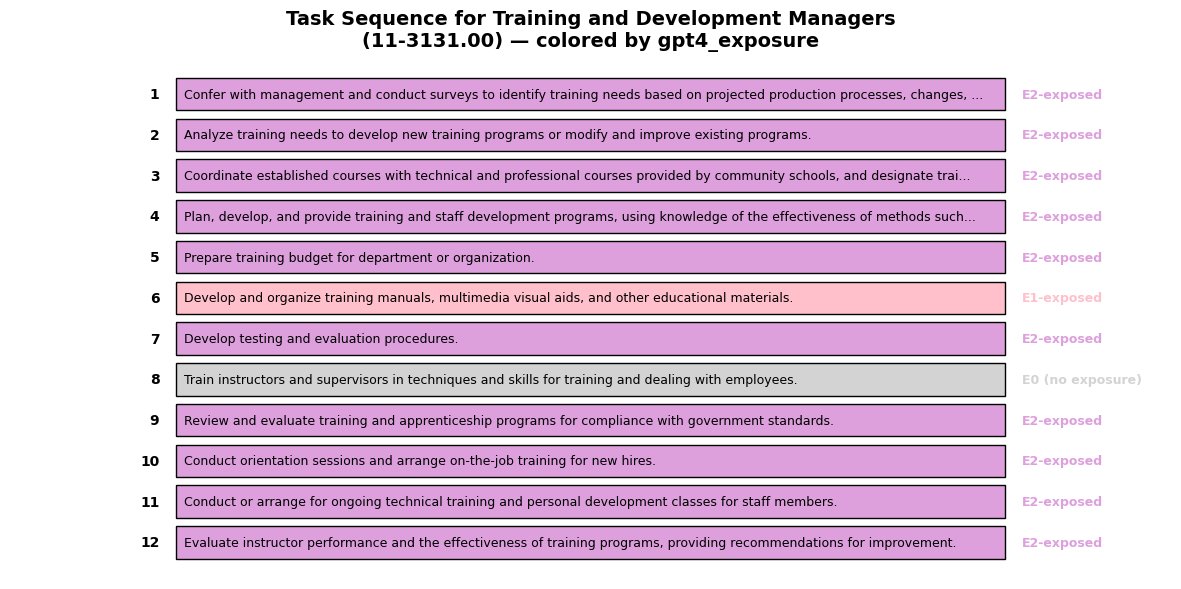

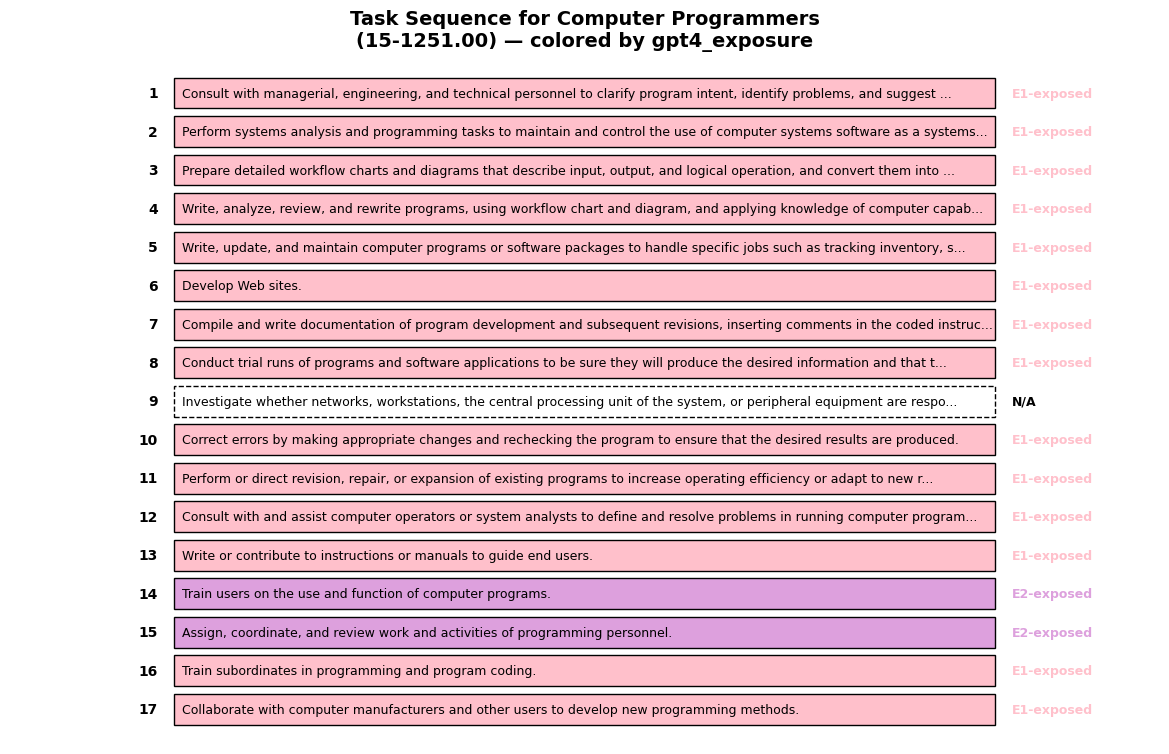

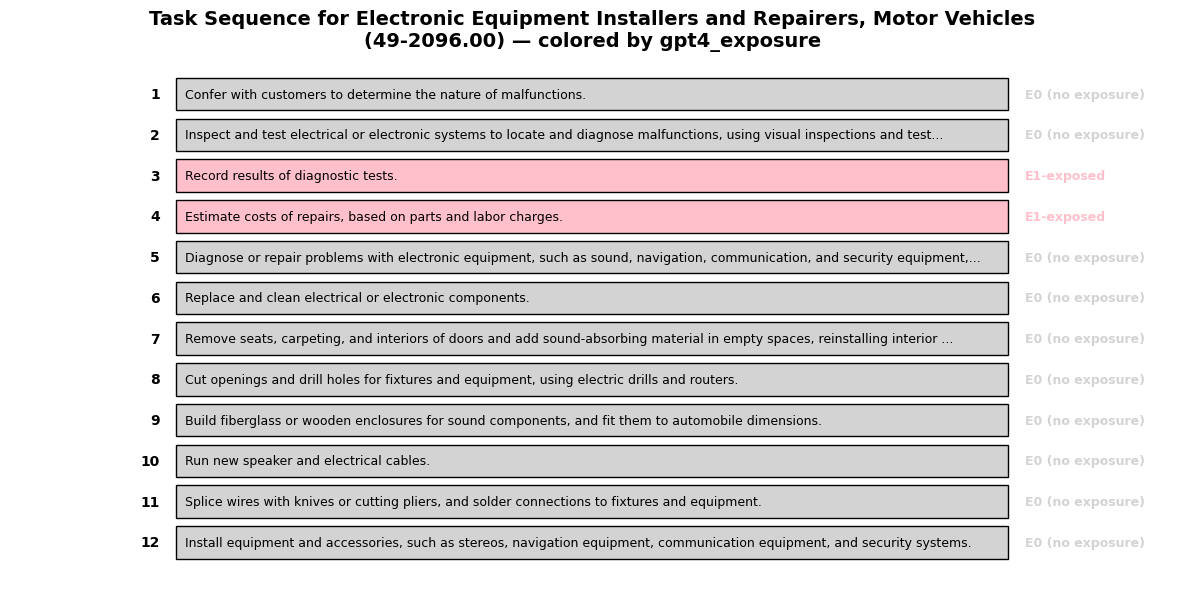

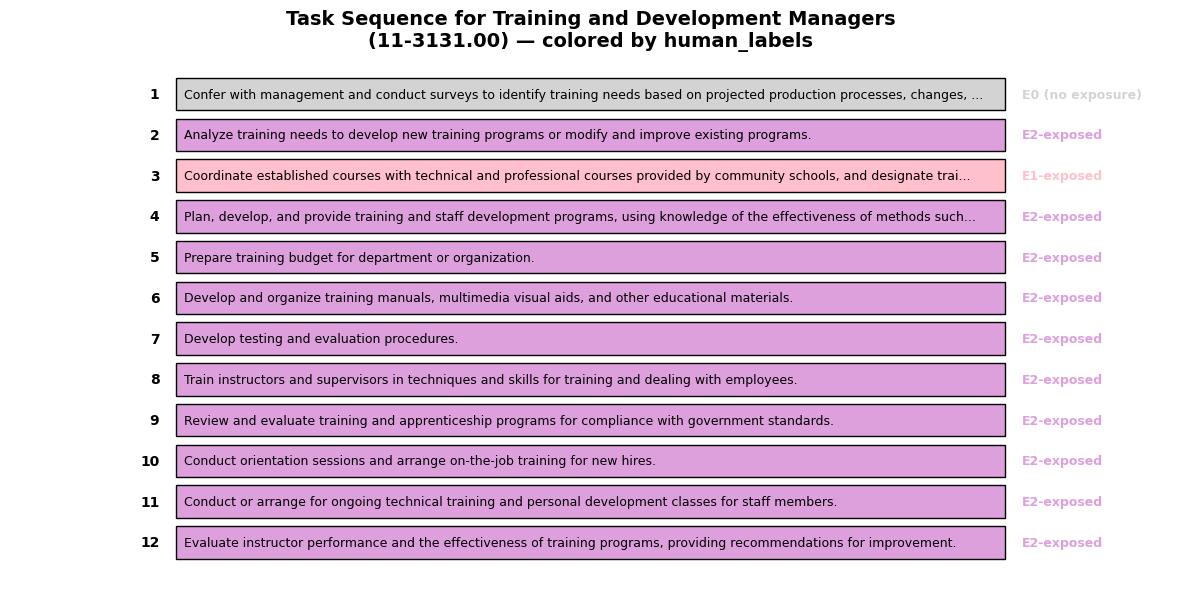

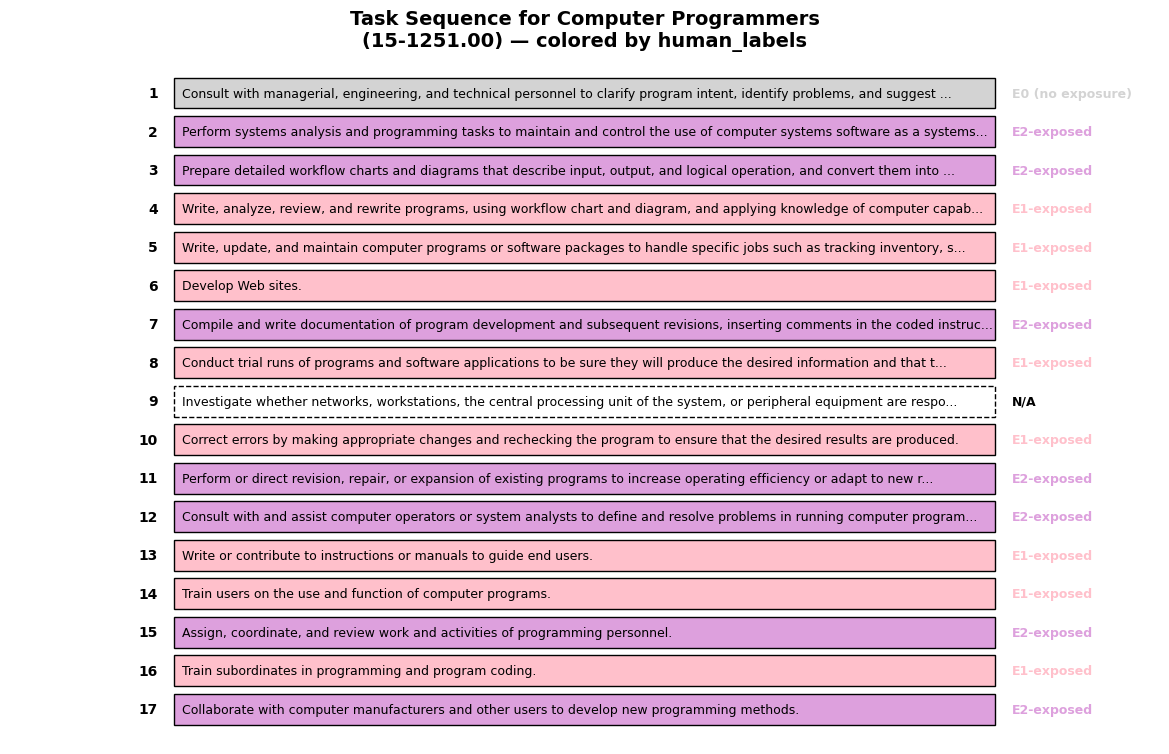

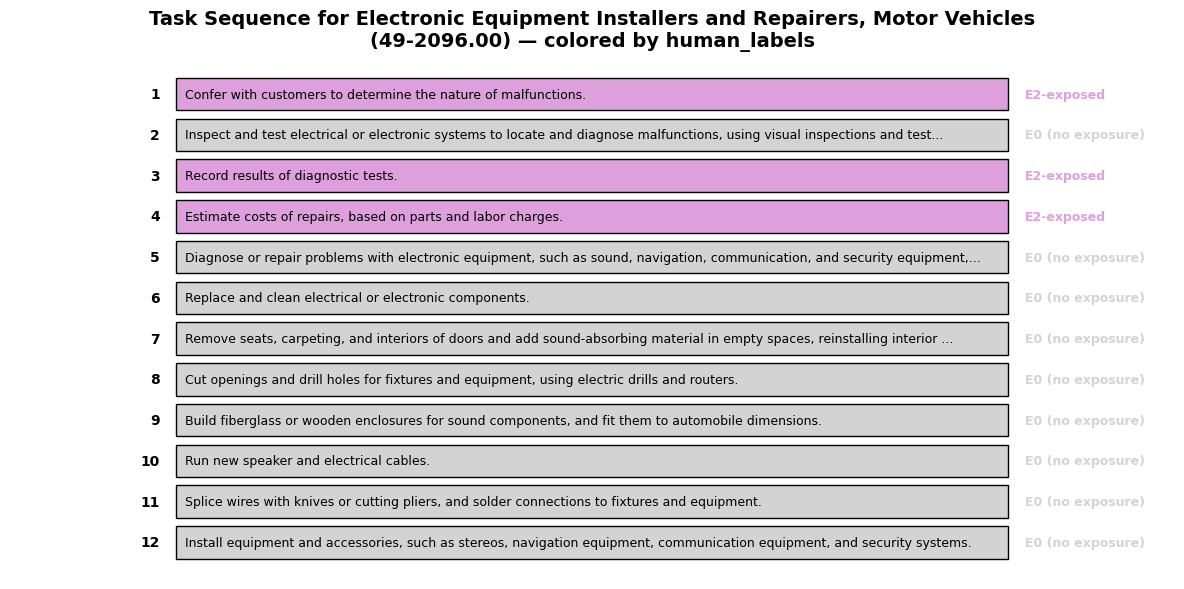

In [7]:
for exposure_col in ['gpt4_exposure', 'human_labels']:
    for occ_code in slide_occupations:
        fig = plot_task_sequence_exposure(merged_data, occ_code, exposure_col)
        if fig is not None:
            plt.show()